-> Successfully parsed file as an Excel Workbook container.

Data Ingestion Metrics Summary:
Training Timeline: 1991-01 to 2019-04
Testing Timeline:  2019-05 to 2026-05



c:\Users\jiaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\jiaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



--- Model Evaluation ---
ARIMA Baseline Test RMSE: 1.8742
ARIMA Baseline Test MAPE: 192.39%


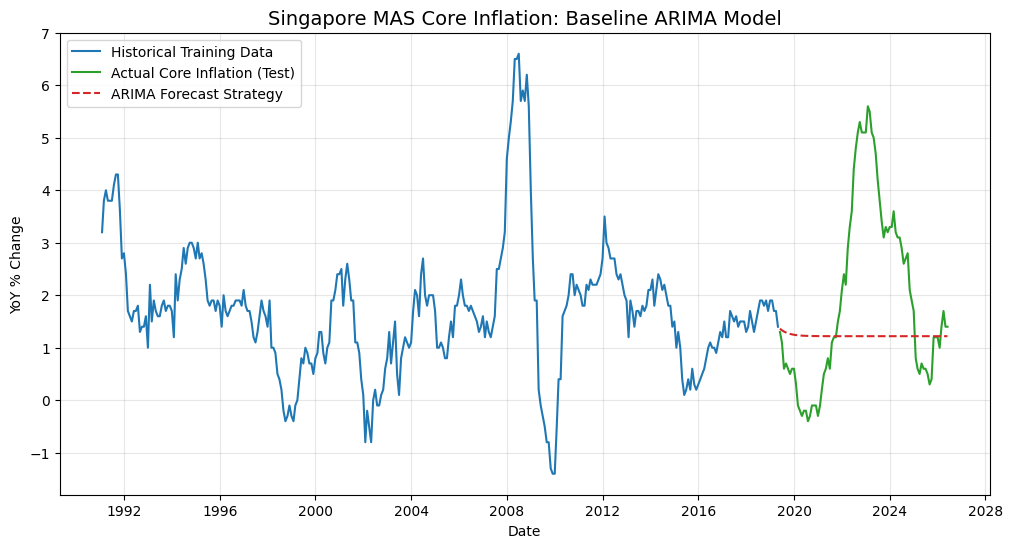

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# ==========================================
# 1. BINARY-SAFE DATA LOAD
# ==========================================
file_name = "MAS Core Inflation.xlsx"


df = pd.read_excel(file_name)
print("-> Successfully parsed file as an Excel Workbook container.")


# Clean whitespace from column headers
df.columns = df.columns.str.strip()

# Explicitly cast the Date series
df["Period"] = pd.to_datetime(df["Period"].astype(str).str.strip(), errors="coerce")
df.dropna(subset=["Period"], inplace=True)

# Sort chronologically (oldest dates first)
df = df.sort_values("Period")
df.set_index("Period", inplace=True)

# Parse target column
df["YOY % Change"] = pd.to_numeric(df["YOY % Change"], errors='coerce')
df.dropna(subset=["YOY % Change"], inplace=True)

# Set clean time-series frequency to Month End
try:
    target = df["YOY % Change"].asfreq("ME")
except ValueError:
    target = df["YOY % Change"].asfreq("M")

target = target.ffill()

# ==========================================
# 2. CHRONOLOGICAL TRAIN / TEST SPLIT
# ==========================================
train_size = int(len(target) * 0.8)
train, test = target.iloc[:train_size], target.iloc[train_size:]

print(f"\nData Ingestion Metrics Summary:")
print(f"Training Timeline: {train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')}")
print(f"Testing Timeline:  {test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')}\n")

# ==========================================
# 3. FIT THE ARIMA BASELINE
# ==========================================
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
#print(model_fit.summary())

# ==========================================
# 4. OUT-OF-SAMPLE FORECAST & EVALUATE
# ==========================================
predictions = model_fit.forecast(steps=len(test))
predictions.index = test.index

rmse = np.sqrt(mean_squared_error(test, predictions))
mape = mean_absolute_percentage_error(test, predictions)

print("\n--- Model Evaluation ---")
print(f"ARIMA Baseline Test RMSE: {rmse:.4f}")
print(f"ARIMA Baseline Test MAPE: {mape * 100:.2f}%")

# ==========================================
# 5. GENERATE CHART
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Historical Training Data", color="#1f77b4")
plt.plot(test.index, test, label="Actual Core Inflation (Test)", color="#2ca02c")
plt.plot(predictions.index, predictions, label="ARIMA Forecast Strategy", color="#d62728", linestyle="--")
plt.title("Singapore MAS Core Inflation: Baseline ARIMA Model", fontsize=14)
plt.xlabel("Date")
plt.ylabel("YoY % Change")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Loading and cleaning individual datasets...
Merging into a single master dataframe...

Timeline: Jan 1998 to May 2026
Total Master Rows Available: 341

Generating economic lag features...
Training Data: 263 months
Testing Data: 66 months

Starting Grid Search...

--- Optimal Hyperparameters Found ---
Random Forest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
XGBoost: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}

--- Final Model Performance (Test Set) ---
Tuned Random Forest -> Test RMSE: 0.3122 | Test MAPE: 19.41%
Tuned XGBoost -> Test RMSE: 0.5469 | Test MAPE: 29.43%


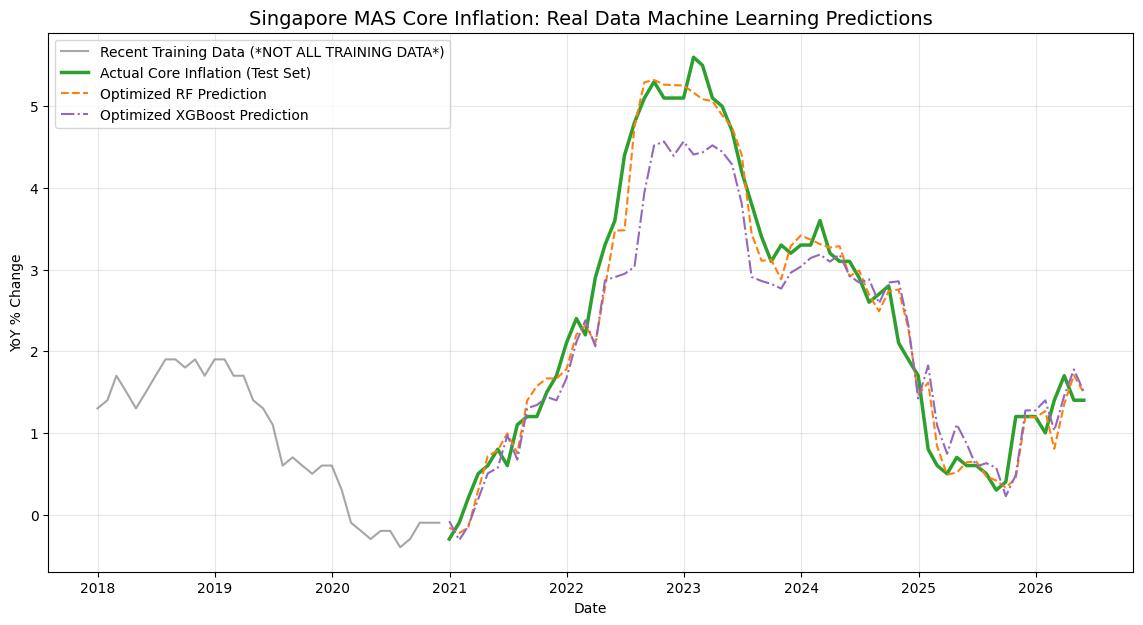

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# ==========================================
# 1. DATA LOADING & INGESTION
# ==========================================
def create_master_dataset():
    print("Loading and cleaning individual datasets...")

    # 1. Load MAS Core Inflation
    df_inflation = pd.read_excel("MAS Core Inflation.xlsx")
    df_inflation['Period'] = pd.to_datetime(df_inflation['Period'], errors='coerce')
    df_inflation = df_inflation.dropna(subset=['Period'])
    df_inflation.set_index('Period', inplace=True)
    df_inflation = df_inflation[['YOY % Change']].rename(columns={'YOY % Change': 'Core_Inflation_YOY'})
    df_inflation = df_inflation.resample('ME').last()

    # 2. Load S$NEER (NNSGBIS)
    df_neer = pd.read_csv("NNSGBIS.csv")
    df_neer['observation_date'] = pd.to_datetime(df_neer['observation_date'], errors='coerce')
    df_neer.set_index('observation_date', inplace=True)
    df_neer = df_neer[['NNSGBIS']].rename(columns={'NNSGBIS': 'NEER'})
    df_neer = df_neer.resample('ME').mean()

    # 3. Load Brent Crude Oil (POILBREUSDM)
    df_oil = pd.read_csv("POILBREUSDM.csv")
    df_oil['observation_date'] = pd.to_datetime(df_oil['observation_date'], errors='coerce')
    df_oil.set_index('observation_date', inplace=True)
    df_oil = df_oil[['POILBREUSDM']]
    df_oil = df_oil.resample('ME').mean()

    # 4. Load GSCPI
    df_gscpi = pd.read_excel("gscpi_data.xls", sheet_name="GSCPI Monthly Data", usecols=[0, 1])
    df_gscpi['Date'] = pd.to_datetime(df_gscpi['Date'], errors='coerce')
    df_gscpi = df_gscpi.dropna(subset=['Date'])
    df_gscpi.set_index('Date', inplace=True)
    df_gscpi['GSCPI'] = pd.to_numeric(df_gscpi['GSCPI'], errors='coerce')
    df_gscpi = df_gscpi.resample('ME').mean()

    print("Merging into a single master dataframe...")
    
    # 5. Combine all dataframes
    master_df = pd.concat([df_inflation, df_neer, df_oil, df_gscpi], axis=1, join='inner')
    return master_df

master_df = create_master_dataset()

print(f"\nTimeline: {master_df.index.min().strftime('%b %Y')} to {master_df.index.max().strftime('%b %Y')}")
print(f"Total Master Rows Available: {len(master_df)}")

# ==========================================
# 2. TARGETED FEATURE ENGINEERING
# ==========================================
print("\nGenerating economic lag features...")
feature_cols = []
short_lags = [1, 2, 3]    # Global shocks & inertia
policy_lags = [6, 9, 12]  # MAS monetary policy

for lag in short_lags:
    master_df[f"Inflation_Lag_{lag}"] = master_df["Core_Inflation_YOY"].shift(lag)
    master_df[f"GSCPI_Lag_{lag}"] = master_df["GSCPI"].shift(lag)
    master_df[f"Oil_Lag_{lag}"] = master_df["POILBREUSDM"].shift(lag)
    feature_cols.extend([f"Inflation_Lag_{lag}", f"GSCPI_Lag_{lag}", f"Oil_Lag_{lag}"])

for lag in policy_lags:
    master_df[f"NEER_Lag_{lag}"] = master_df["NEER"].shift(lag)
    feature_cols.append(f"NEER_Lag_{lag}")

# Drop rows with NaNs introduced by the 12-month lag shifts
master_df.dropna(inplace=True)

X = master_df[feature_cols]
y = master_df["Core_Inflation_YOY"]

# ==========================================
# 3. CHRONOLOGICAL TRAIN/TEST SPLIT
# ==========================================
train_size = int(len(master_df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training Data: {len(X_train)} months")
print(f"Testing Data: {len(X_test)} months")

# ==========================================
# 4. GRID SEARCH CV WITH TIME-SERIES SPLIT
# ==========================================
tscv = TimeSeriesSplit(n_splits=3)
print("\nStarting Grid Search...")

# --- A. Random Forest Tuning ---

rf_param_grid = {
    'n_estimators': [50, 100, 200, 300], 
    'max_depth': [3, 5, 7, 10], 
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4] 
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_

# --- B. XGBoost Tuning ---

xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [2, 3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
best_xgb_model = xgb_grid.best_estimator_

print("\n--- Optimal Hyperparameters Found ---")
print(f"Random Forest: {rf_grid.best_params_}")
print(f"XGBoost: {xgb_grid.best_params_}")

# ==========================================
# 5. PREDICT & EVALUATE WITH BEST MODELS
# ==========================================
rf_preds = pd.Series(best_rf_model.predict(X_test), index=y_test.index)
xgb_preds = pd.Series(best_xgb_model.predict(X_test), index=y_test.index)

print("\n--- Final Model Performance (Test Set) ---")
for name, preds in [("Tuned Random Forest", rf_preds), ("Tuned XGBoost", xgb_preds)]:
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = mean_absolute_percentage_error(y_test, preds)
    print(f"{name} -> Test RMSE: {rmse:.4f} | Test MAPE: {mape * 100:.2f}%")

# ==========================================
# 6. VISUALIZE RESULTS
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(y_train.index[-36:], y_train.iloc[-36:], label="Recent Training Data (*NOT ALL TRAINING DATA*)", color="gray", alpha=0.7)
plt.plot(y_test.index, y_test, label="Actual Core Inflation (Test Set)", color="#2ca02c", linewidth=2.5)
plt.plot(rf_preds.index, rf_preds, label="Optimized RF Prediction", color="#ff7f0e", linestyle="--")
plt.plot(xgb_preds.index, xgb_preds, label="Optimized XGBoost Prediction", color="#9467bd", linestyle="-.")

plt.title("Singapore MAS Core Inflation: Real Data Machine Learning Predictions", fontsize=14)
plt.xlabel("Date")
plt.ylabel("YoY % Change")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()